In [36]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


class state(TypedDict):
   # Message have the type "list". The `add_messages` function will convert it to a list of messages.
   # in the Annotated type, we specify that the value of "message" is a list of strings.
   # (in this case, it append message to the list, eather than overwriting them)
   messages: Annotated[list,add_messages]
                       


In [37]:
graph_builder = StateGraph(state)
graph_builder

In [38]:
import os
from dotenv import load_dotenv
load_dotenv()


True

In [39]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(
    model="llama-3.1-8b-instant",
)
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x11521d150>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x11521e050>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [40]:
llm = init_chat_model("groq:llama-3.1-8b-instant")
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x115214bd0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x115215f10>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [41]:
from typing import Any, Dict
State = Dict[str, Any]

def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

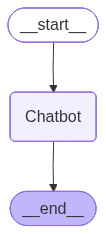

In [42]:
graph_builder = StateGraph(state)
# ADD NODES 
graph_builder.add_node("Chatbot", chatbot)
# ADD EDGES
graph_builder.add_edge(START, "Chatbot")
# ADD EDGE TO END NODE
graph_builder.add_edge("Chatbot", END)

# COMPILE THE GRAPH
graph = graph_builder.compile()

graph


In [43]:
res = graph.invoke({
    "messages": [("user", "What is the capital of France?")],
})

res["messages"][-1].content

'The capital of France is Paris.'

In [44]:
for event in graph.stream({
    "messages": [("user", "What is the capital of France?")]
}):
    for value in event.values():
        print(value["messages"][-1].content)    

The capital of France is Paris.


# Chatbot with Tool


In [45]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=3)

tool.invoke("What is langraph?")

{'query': 'What is langraph?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://medium.com/@jagadeesan.ganesh/a-comprehensive-guide-to-langraph-step-by-step-with-examples-56ab31a987ee',
   'title': 'A Comprehensive Guide to Langraph: Step-by-Step with Examples',
   'content': 'Langraph is an emerging technology in the world of natural language processing (NLP), focusing on simplifying complex interactions between humans and AI agents.',
   'score': 0.9245858,
   'raw_content': None},
  {'url': 'https://www.datacamp.com/tutorial/langgraph-tutorial',
   'title': 'LangGraph Tutorial: What Is LangGraph and How to Use It? | DataCamp',
   'content': "# LangGraph Tutorial: What Is LangGraph and How to Use It? LangGraph is a library within the LangChain ecosystem that provides a framework for defining, coordinating, and executing multiple LLM agents (or chains) in a structured and efficient manner. Imagine you're building a complex, multi-agent large 

In [46]:
## Custom function
def multiply(a:int, b:int) -> int:
    """Multiply a and b
   
   Args:
     a (int): first number
     b (int): second number

   Returns:
     int: output int
   """
    return a * b

In [47]:
tools = [tool, multiply]

In [48]:
llm_with_tools = llm.bind_tools(tools)

In [49]:
llm_with_tools

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x115214bd0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x115215f10>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, a

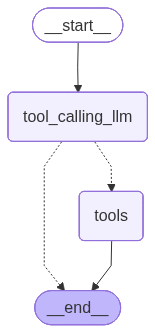

In [50]:
## state graph 
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:state):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## Graph 
builder= StateGraph(state)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If then latest message (result) from assistant is a tol call -> tools_condition routes to tools 
    # If then latest message (result) from assistant is a not tol call -> tools_condition routes to END 
    tools_condition
)

builder.add_edge("tools", END)

## Compile the graph 
graph = builder.compile() 

from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [51]:
graph.invoke({"messages": [("user", "What is the recent ai news?")]})

{'messages': [HumanMessage(content='What is the recent ai news?', additional_kwargs={}, response_metadata={}, id='ffd954ee-ef9c-4632-a66a-c175a0e6a5cd'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '69cgdtxvc', 'function': {'arguments': '{"end_date":null,"exclude_domains":[],"include_domains":[],"include_images":false,"query":"recent AI news","search_depth":"advanced","start_date":null,"time_range":null,"topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 64, 'prompt_tokens': 1752, 'total_tokens': 1816, 'completion_time': 0.095944794, 'completion_tokens_details': None, 'prompt_time': 0.126056614, 'prompt_tokens_details': None, 'queue_time': 0.161675192, 'total_time': 0.222001408}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e781a-83ba-7231-a597-2